# БДЗ 2

In [1]:
import sys
# sys.path.append("src")
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import warnings
warnings.filterwarnings('ignore', message='.*Converting mask without torch.bool.*')

In [2]:
import torch
from torch.utils.data import DataLoader
import torchtext
from pathlib import Path
import sacrebleu
from torch import nn

from src.dataset import TranslationDataset
from src.models.rnn import Seq2Seq
from src.inference import translate_file
from src.train import train
from src.prepare_spm import train_sentencepiece
from src.models.transformer import TransformerMT
from src.models.transformer2 import TransformerMT2

In [3]:
print(f"PyTorch версия: {torch.__version__}")
print(f"torchtext версия: {torchtext.__version__}")
print(f"sacrebleu версия: {sacrebleu.__version__}")

PyTorch версия: 2.10.0
torchtext версия: 0.6.0
sacrebleu версия: 2.6.0


In [4]:
# обучение sentencepiece

DATA_DIR = "data"
FORCE_RETRAIN_SPM = False # принудительное пересоздание модели SentencePiece
VOCAB_SIZE = 32000

SPM_MODEL_PATH = Path(DATA_DIR) / "sentencepiece.model"

if not SPM_MODEL_PATH.exists() or FORCE_RETRAIN_SPM:
    print("SentencePiece model not found. Training...")
    train_sentencepiece(
        data_dir=DATA_DIR,
        vocab_size=VOCAB_SIZE,
        model_prefix="bpe"
    )
else:
    print("SentencePiece model already exists.")

SentencePiece model already exists.


In [5]:
# даталоадеры

BATCH_SIZE = 64

train_ds = TranslationDataset(
    "train.de-en.de",
    "train.de-en.en",
    "sentencepiece.model",
    DATA_DIR
)

val_ds = TranslationDataset(
    "val.de-en.de",
    "val.de-en.en",
    "sentencepiece.model",
    DATA_DIR
)

PAD = train_ds.PAD
vocab_size = train_ds.vocab_size + 3

def make_collate(pad):
    def collate_fn(batch):
        srcs, tgts = zip(*batch)
        max_src = max(s.size(0) for s in srcs)
        max_tgt = max(t.size(0) for t in tgts)
        padded_src = torch.full((len(batch), max_src), pad, dtype=torch.long)
        padded_tgt = torch.full((len(batch), max_tgt), pad, dtype=torch.long)
        for i,(s,t) in enumerate(batch):
            padded_src[i, :s.size(0)] = s
            padded_tgt[i, :t.size(0)] = t
        src_lens = torch.LongTensor([s.size(0) for s in srcs])
        tgt_lens = torch.LongTensor([t.size(0) for t in tgts])
        return padded_src, src_lens, padded_tgt, tgt_lens
    return collate_fn

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=make_collate(PAD)
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=make_collate(PAD)
)

In [6]:
# обрезка датасета для быстрого тестирования
DEBUG = False
DEBUG_SAMPLES = 20000

if DEBUG:
    train_ds.src_lines = train_ds.src_lines[:DEBUG_SAMPLES]
    train_ds.tgt_lines = train_ds.tgt_lines[:DEBUG_SAMPLES]

    print("Running in DEBUG mode")
    print("Train size:", len(train_ds))
    print("Val size:", len(val_ds))

In [7]:
# параметры обучения
NUM_EPOCHS = 50

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
# device = torch.device("cpu")


# CHATGPT TRANSFORMER

model = TransformerMT(
    vocab_size=vocab_size,
    emb_size=256,
    nhead=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    pad_idx=train_ds.PAD,
    max_len=512
).to(device)

# GROK TRANSFORMER

# model = TransformerMT2(
#     vocab_size=vocab_size,
#     d_model=512,
#     nhead=8,
#     num_encoder_layers=6,
#     num_decoder_layers=6,
#     dim_feedforward=2048,
#     dropout=0.1,
#     pad_idx=PAD,
#     max_len=512,
# ).to(device)


# optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-6)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.10)

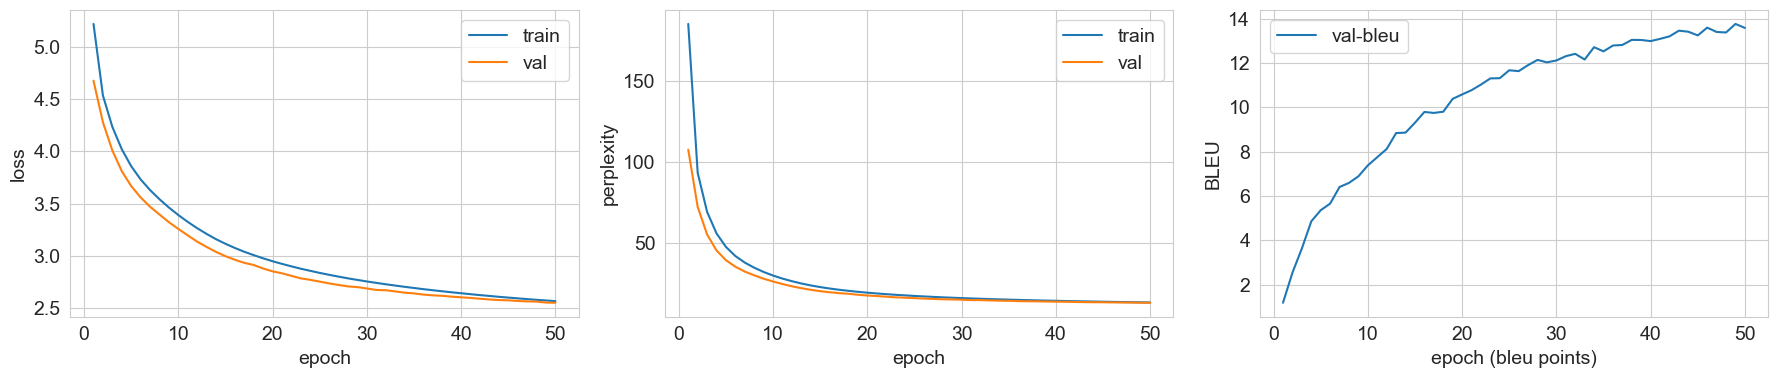

In [8]:
train_losses, val_losses, train_ppls, val_ppls, val_bleus = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    pad_idx=PAD,
    num_epochs=NUM_EPOCHS,
    val_dataset=val_ds,
    max_decoding_len=50,
    bleu_every=1,
    tmp_val_out="outputs/val_predictions.en",
    device=device,
    plot=True
)

In [13]:
# BLEU на валидации

val_src = open("data/val.de-en.de", encoding="utf-8").read().splitlines()
val_ref = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

VAL_OUTPUT_PATH = "outputs/val_predictions.en"

translate_file(
    model=model,
    dataset=val_ds,
    input_lines=val_src,
    device=device,
    output_path=VAL_OUTPUT_PATH,
    max_decoding_len=50
)

val_pred = open(VAL_OUTPUT_PATH, encoding="utf-8").read().splitlines()

bleu = sacrebleu.corpus_bleu(val_pred, [val_ref], tokenize='none')
print("Validation BLEU:", bleu.score)

Validation BLEU: 13.544398644603397


In [11]:
# примеры вывода

val_pred = open("outputs/val_predictions.en", encoding="utf-8").read().splitlines()
val_ref  = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

print("counts: pred =", len(val_pred), "ref =", len(val_ref))

for i in range(10):
    print(f"\n=== Example {i} ===")
    print("PRED repr:", repr(val_pred[i]))
    print("REF  repr:", repr(val_ref[i]))

counts: pred = 986 ref = 986

=== Example 0 ===
PRED repr: 'when i was 11 years old , i was a singing of the sound of the sounder joy . " right ? " i was borrowed . " i was a threat . " and i'
REF  repr: 'when i was 11 , i remember waking up one morning to the sound of joy in my house .'

=== Example 1 ===
PRED repr: 'my father heard on his little , gray radio shows the bbc . " right ? " " " " my father . " " " " my father . " " " " " listen . " " " li'
REF  repr: 'my father was listening to bbc news on his small , gray radio .'

=== Example 2 ===
PRED repr: 'he looked very happy what was quite unusual , because the news depressed most of the news . " right ? " and he looked very happy . " and he looked very happy . "'
REF  repr: 'there was a big smile on his face which was unusual then , because the news mostly depressed him .'

=== Example 3 ===
PRED repr: 'he called , " the taliban are gone ! " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " "'
REF  repr: '" the tali

In [12]:
# прогноз для тестового набора

test_lines = open("data/test1.de-en.de", encoding="utf-8").read().splitlines()

OUTPUT_PATH = "outputs/test1.de-en.en"

translate_file(
    model=model,
    dataset=train_ds,
    input_lines=test_lines,
    device=device,
    output_path=OUTPUT_PATH,
    max_decoding_len=50
)

print(f"Test translations saved to {OUTPUT_PATH}")

Test translations saved to outputs/test1.de-en.en
